**intro** — описание вашего финального решения с такими пунктами:
1) как обработали данные;
2) какой алгоритм вы выбрали;
3) какие особенности использовали при его обучении;
4) как проводили валидацию алгоритма.

**Обработка данных**

- **Заполнение пропусков и преобразование признаков:**
Для корректной работы модели пропуски в колонках, таких как host_name, были заполнены значением 'unknown'. Признаки, связанные с отзывами (например, amt_reviews и avg_reviews), заполнялись нулями или медианными значениями.
Кроме того, дата последнего отзыва преобразовывалась в формат datetime, из которого вычислялись дополнительные признаки: количество дней с последнего отзыва (days_since_review), год и месяц последнего отзыва.

- **Удаление неинформативных столбцов:**
Удалены колонки _id, name и last_dt, которые не несут полезной информации для модели.

- **Удаление линейно-зависимых фичей**
'host_listings_percent', 'last_review_year', 'sum' показывают высокую корреляцию

- **Создание новых признаков:**
Функция add_features дополнительно формирует признаки, такие как:

-     Кластеризация географических координат с помощью KMeans (20 кластеров) для получения категориального признака location_cluster_kmeans.

-     Вычисление доли объявлений хоста (host_listings_percent) и цены за день (price_per_day).

**Выбор алгоритма**
- Для решения задачи регрессии выбран CatBoostRegressor. Этот алгоритм отлично работает с категориальными данными, так как позволяет напрямую передавать список категориальных признаков через параметр cat_features, а также устойчив к выбросам, что является важным при работе с реальными данными.

**Особенности обучения модели**

- **Оптимизация гиперпараметров:**
Использовался GridSearchCV для подбора оптимальной комбинации гиперпараметров, таких как количество итераций (iterations), скорость обучения (learning_rate), глубина дерева (depth) и коэффициент регуляризации (l2_leaf_reg).

- **Масштабирование числовых признаков:**
Применялся RobustScaler для масштабирования числовых признаков, что позволяет уменьшить влияние выбросов.

- **Стратифицированное разбиение:**
Для более равномерного распределения целевой переменной данные разделялись на группы с использованием pd.qcut, что обеспечивало сохранение пропорций при разбиении на обучающую и тестовую выборки.

**Валидация алгоритма**

- **Разделение выборок:**
Данные были разделены на обучающую и тестовую выборки с использованием функции train_test_split, при этом стратификация проводилась по созданному признаку target_bin, полученному из разбиения целевой переменной на 10 квантилей.

- **Кросс-валидация:**
Для оценки качества модели и подбора оптимальных гиперпараметров применялась трёхфолдовая кросс-валидация внутри GridSearchCV.

**Оценка метрики:**
Качество модели оценивалось с использованием метрики MSE на тестовой выборке, что позволило объективно сравнить результаты разных конфигураций модели.

Это решение обеспечивает комплексный подход к подготовке данных, выбору и обучению модели, а также надежной валидации результатов, что является важным для достижения высоких показателей на тестовой выборке.


________________
Также были проведены другие подходы решения данной задачи, одним из них я делилась в чате. Кратко напомню: 

Использование двухступенчатой модели. На первом этапе применяется классификатор для определения, является ли значение нулевым или положительным. Если прогноз положительный – на втором этапе применяется регрессионная модель для оценки конкретного значения. Такое разделение задачи на классификацию и регрессию позволяет детально проработать прогнозирование только для положительных случаев, что существенно улучшает точность предсказаний.

Что касается применимости данного решения в бизнес-процессах:
 Двухступенчатый подход можно использовать для сегментации клиентов: сначала классифицировать, будут ли они совершать покупки (0 или 1), а затем предсказывать сумму покупки.  Разделение задачи позволяет сосредоточиться на специфических аспектах проблемы – сначала выявить потенциальных клиентов, затем оценить их ценность. Это повышает точность прогнозов и позволяет принимать более обоснованные решения.

In [12]:
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt

/Users/katiegalaeva/miniconda3/envs/catboost_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from sklearn import set_config
set_config(transform_output="pandas")

In [13]:
train = pd.read_csv('train.csv')
train

,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Manhattan Apartment - Near North Central Park,108286255,Gabrielle,Manhattan,Harlem,40.81264,-73.94231,Private room,60,1,3,2019-01-01,0.46,1,0
36667,Elegant 1876 Boerum Hill Brownstone,16395150,Patti,Brooklyn,Boerum Hill,40.68554,-73.98471,Entire home/apt,265,2,10,2016-09-07,0.18,1,0
36668,Super cute and sunny 2 bedroom,39304,Andrea,Brooklyn,Williamsburg,40.71852,-73.94165,Entire home/apt,240,365,0,NaN,NaN,1,363
36669,TWO BIG Rooms - a Park Slope Oasis,15942513,Tom,Brooklyn,South Slope,40.66617,-73.98862,Private room,90,2,15,2019-06-18,2.34,1,91


**Обработка данных**
-Заполнение пропусков:
В функции preprocess_data заполняем пропуски в колонке host_name значением 'unknown'. Аналогично для тестовой выборки в функции preprocess_data_test заполняются пропуски в amt_reviews значением 0 и в avg_reviews значением медианы.
-Работа с датами:
Преобразуем строковое представление даты в тип datetime, рассчитываем количество дней с последнего отзыва и выделяем год и месяц последнего отзыва.
-Удаление ненужных колонок:
После формирования новых признаков удаляются колонки, которые не несут полезной информации (например, _id, name и last_dt).

In [14]:
def preprocess_data(df):

    df['host_name'].fillna('unknown', inplace=True)
    df['amt_reviews'].fillna(0, inplace=True)
    df['avg_reviews'].fillna(df['avg_reviews'].median(), inplace=True)
    
   
    df['last_dt'] = pd.to_datetime(df['last_dt'])
    df['days_since_review'] = (datetime.now() - df['last_dt']).dt.days
    df['last_review_year'] = df['last_dt'].dt.year
    df['last_review_month'] = df['last_dt'].dt.month
   
    #df['target'] = np.log1p(df['target'])  
   
    df.drop(['_id', 'name', 'last_dt'], axis=1, inplace=True)
    
    return df

In [15]:
def add_features(df):
  
    from sklearn.cluster import KMeans
    coords = df[['lat', 'lon']].dropna()
    kmeans = KMeans(n_clusters=20, random_state=42).fit(coords)
    df['location_cluster_kmeans'] = kmeans.predict(df[['lat', 'lon']])
    

    df['host_listings_percent'] = df['total_host'] / df['total_host'].max()
    
  
    df['price_per_day'] = df['sum'] / (df['min_days'] + 1)
    
    return df

In [33]:
train = preprocess_data(train)

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_28887/1882586460.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna('unknown', inplace=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_28887/1882586460.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [16]:
train = add_features(train)

In [17]:
train

,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target,location_cluster_kmeans,host_listings_percent,price_per_day
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334,13,0.003058,116.666667
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0,7,0.003058,6.666667
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0,11,0.003058,33.333333
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0,3,0.003058,21.666667
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155,2,0.003058,33.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Manhattan Apartment - Near North Central Park,108286255,Gabrielle,Manhattan,Harlem,40.81264,-73.94231,Private room,60,1,3,2019-01-01,0.46,1,0,3,0.003058,30.000000
36667,Elegant 1876 Boerum Hill Brownstone,16395150,Patti,Brooklyn,Boerum Hill,40.68554,-73.98471,Entire home/apt,265,2,10,2016-09-07,0.18,1,0,7,0.003058,88.333333
36668,Super cute and sunny 2 bedroom,39304,Andrea,Brooklyn,Williamsburg,40.71852,-73.94165,Entire home/apt,240,365,0,NaN,NaN,1,363,9,0.003058,0.655738
36669,TWO BIG Rooms - a Park Slope Oasis,15942513,Tom,Brooklyn,South Slope,40.66617,-73.98862,Private room,90,2,15,2019-06-18,2.34,1,91,7,0.003058,30.000000


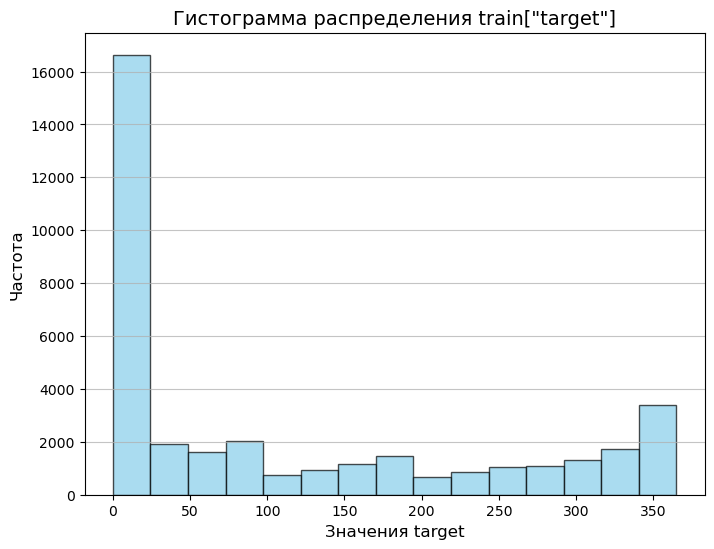

In [ ]:


plt.figure(figsize=(8, 6))
plt.hist(train['target'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Значения target', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Гистограмма распределения train["target"]', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [ ]:
train = train.drop(columns=['host_name',	'location_cluster',	'location', 'type_house'])

In [26]:
train = train.drop(columns=['last_dt'])

In [27]:
train

,_id,lat,lon,sum,min_days,amt_reviews,avg_reviews,total_host,target,location_cluster_kmeans,host_listings_percent,price_per_day
0,40327248,40.57215,-73.85822,350,2,5,2.88,1,334,13,0.003058,116.666667
1,13617520,40.69172,-73.96934,40,5,8,0.13,1,0,7,0.003058,6.666667
2,26754726,40.77673,-73.98011,200,5,0,NaN,1,0,11,0.003058,33.333333
3,16721721,40.81530,-73.95080,65,2,18,0.64,1,0,3,0.003058,21.666667
4,22246463,40.70230,-73.92935,99,2,26,0.76,1,155,2,0.003058,33.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
36666,108286255,40.81264,-73.94231,60,1,3,0.46,1,0,3,0.003058,30.000000
36667,16395150,40.68554,-73.98471,265,2,10,0.18,1,0,7,0.003058,88.333333
36668,39304,40.71852,-73.94165,240,365,0,NaN,1,363,9,0.003058,0.655738
36669,15942513,40.66617,-73.98862,90,2,15,2.34,1,91,7,0.003058,30.000000


Проведем проверку на корреляцию данных

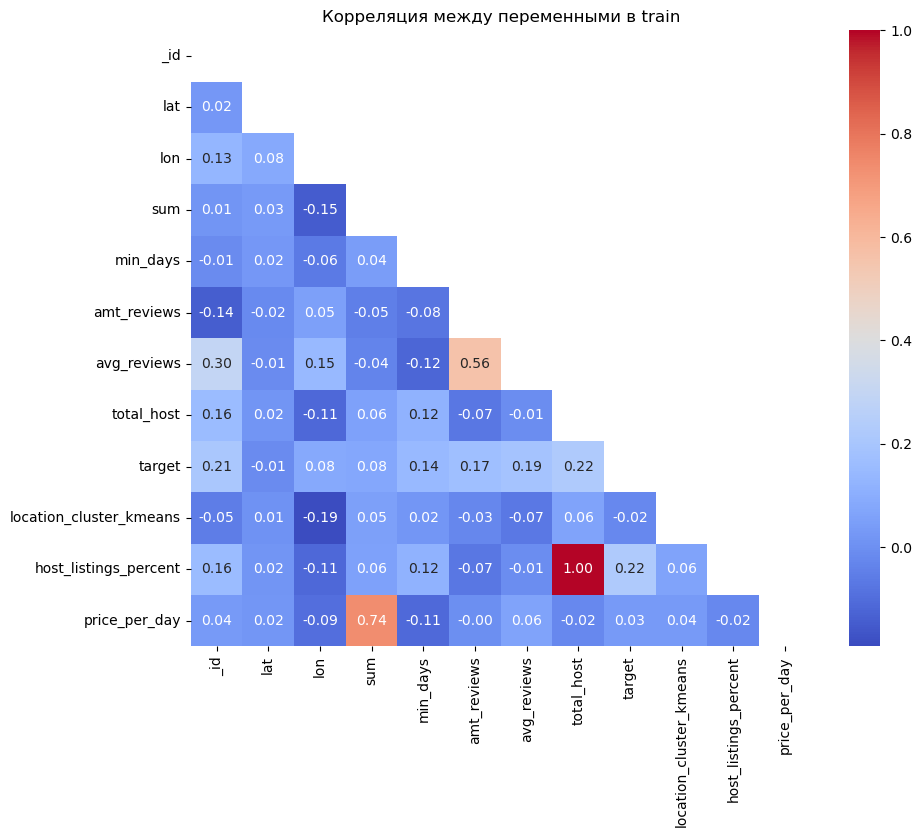

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


corr_matrix = train.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция между переменными в train")
plt.show()


Фичи host_listings_percent, last_review_year, sum сильно коррелируют между собой - поэтому удаляем эти фичи из датасета.

In [ ]:
train = train.drop(columns=['host_listings_percent'])
train = train.drop(columns=['sum'])

In [40]:
train.isna().sum()

host_name                     0
location_cluster              0
location                      0
lat                           0
lon                           0
type_house                    0
min_days                      0
amt_reviews                   0
avg_reviews                   0
total_host                    0
target                        0
days_since_review          7502
last_review_month          7502
location_cluster_kmeans       0
price_per_day                 0
dtype: int64

In [41]:
train

,host_name,location_cluster,location,lat,lon,type_house,min_days,amt_reviews,avg_reviews,total_host,target,days_since_review,last_review_month,location_cluster_kmeans,price_per_day
0,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,2,5,2.88,1,334,2089.0,7.0,13,116.666667
1,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,5,8,0.13,1,0,3682.0,2.0,7,6.666667
2,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,5,0,0.72,1,0,NaN,NaN,11,33.333333
3,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,2,18,0.64,1,0,2334.0,11.0,3,21.666667
4,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,2,26,0.76,1,155,2103.0,6.0,2,33.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Gabrielle,Manhattan,Harlem,40.81264,-73.94231,Private room,1,3,0.46,1,0,2276.0,1.0,3,30.000000
36667,Patti,Brooklyn,Boerum Hill,40.68554,-73.98471,Entire home/apt,2,10,0.18,1,0,3122.0,9.0,7,88.333333
36668,Andrea,Brooklyn,Williamsburg,40.71852,-73.94165,Entire home/apt,365,0,0.72,1,363,NaN,NaN,9,0.655738
36669,Tom,Brooklyn,South Slope,40.66617,-73.98862,Private room,2,15,2.34,1,91,2108.0,6.0,7,30.000000


Работа с категориальными и числовыми признаками:
Категориальные признаки передаются непосредственно в модель через параметр cat_features, а числовые признаки масштабируются с использованием RobustScaler для устойчивости к выбросам.

In [21]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

In [22]:
numeric_columns = ['lat', 'lon', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'days_since_review', 'last_review_month', 'price_per_day']
train_scaled= train.copy()
train[numeric_columns] = scaler.fit_transform(train[numeric_columns])
train

,host_name,location_cluster,location,lat,lon,type_house,min_days,amt_reviews,avg_reviews,total_host,target,days_since_review,last_review_month,location_cluster_kmeans,price_per_day
0,Sarina,Queens,Neponsit,-2.063687,2.066447,Entire home/apt,-0.25,0.000000,1.661538,0.0,334,-0.140805,0.5,13,2.504762
1,Howard T.,Brooklyn,Clinton Hill,-0.429548,-0.292538,Shared room,0.50,0.130435,-0.453846,0.0,0,4.436782,-2.0,7,-0.638095
2,Julie,Manhattan,Upper West Side,0.732267,-0.521176,Entire home/apt,0.50,-0.217391,0.000000,0.0,0,NaN,NaN,11,0.123810
3,Federico,Manhattan,Harlem,1.259396,0.101051,Private room,-0.25,0.565217,-0.061538,0.0,0,0.563218,2.5,3,-0.209524
4,Lisa,Brooklyn,Bushwick,-0.284953,0.556417,Private room,-0.25,0.913043,0.030769,0.0,155,-0.100575,0.0,2,0.114286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Gabrielle,Manhattan,Harlem,1.223042,0.281286,Private room,-0.50,-0.086957,-0.200000,0.0,0,0.396552,-2.5,3,0.028571
36667,Patti,Brooklyn,Boerum Hill,-0.514008,-0.618830,Entire home/apt,-0.25,0.217391,-0.415385,0.0,0,2.827586,1.5,7,1.695238
36668,Andrea,Brooklyn,Williamsburg,-0.063277,0.295298,Entire home/apt,90.50,-0.217391,0.000000,0.0,363,NaN,NaN,9,-0.809836
36669,Tom,Brooklyn,South Slope,-0.778734,-0.701836,Private room,-0.25,0.434783,1.246154,0.0,91,-0.086207,0.0,7,0.028571


Использован CatBoostRegressor – алгоритм градиентного бустинга, хорошо работающий с категориальными признаками и устойчивый к выбросам.
Гиперпараметрическая оптимизация:
Использован GridSearchCV для подбора параметров (iterations, learning_rate, depth, l2_leaf_reg), что позволяет найти оптимальную комбинацию гиперпараметров с использованием кросс-валидации.

Создаю новую фичу target_bin на основе непрерывного признака target. Функция pd.qcut делит значения target на 10 квантилей (то есть так, чтобы примерно равное количество наблюдений попадало в каждый интервал). 

In [72]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error


train['target_bin'] = pd.qcut(train['target'], q=10, duplicates='drop')


X = train.drop(['target', 'target_bin'], axis=1)
y = train['target']

cat_columns = ['location_cluster', 'location', 'type_house','host_name']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=train['target_bin']
)

model = CatBoostRegressor(
    loss_function='MSE',  
    cat_features=cat_columns,
    verbose=0 
)


param_grid = {
    'iterations': [1500, 1800],
    'learning_rate': [ 0.01, 0.05, 0.03],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [ 3, 5, 7] 
}


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',  
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Лучшие параметры:", grid_search.best_params_)
print("Лучшее значение MSE (отрицательное):", grid_search.best_score_)


y_pred = grid_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE на тестовой выборке:", rmse)


Лучшие параметры: {'depth': 8, 'iterations': 1800, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Лучшее значение MSE (отрицательное): -10094.840544452554
RMSE на тестовой выборке: 98.72688398436466


Теперь сделаем предсказание на тестовой выборке, но сначала проделаем весь препроцессинг, который был сделан на обучающей выборке. 

In [73]:
test = pd.read_csv('test.csv')

def preprocess_data_test(df):
   
    df['host_name'].fillna('unknown', inplace=True)
    df['amt_reviews'].fillna(0, inplace=True)
    df['avg_reviews'].fillna(df['avg_reviews'].median(), inplace=True)
    
  
    df['last_dt'] = pd.to_datetime(df['last_dt'])
    df['days_since_review'] = (datetime.now() - df['last_dt']).dt.days
    df['last_review_year'] = df['last_dt'].dt.year
    df['last_review_month'] = df['last_dt'].dt.month
    
 
    
  
    df.drop(['_id', 'name', 'last_dt'], axis=1, inplace=True)
    
    return df

test = preprocess_data_test(test)
test = add_features(test)

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_28887/3557832296.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna('unknown', inplace=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_28887/3557832296.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [74]:
test = test.drop(columns=['host_listings_percent'])
test = test.drop(columns=['last_review_year', 'sum'])

In [75]:
test.isna().sum()

host_name                     0
location_cluster              0
location                      0
lat                           0
lon                           0
type_house                    0
min_days                      0
amt_reviews                   0
avg_reviews                   0
total_host                    0
days_since_review          2550
last_review_month          2550
location_cluster_kmeans       0
price_per_day                 0
dtype: int64

In [76]:
y_pred = grid_search.predict(test)

In [77]:
y_pred

array([239.74294714, 179.18367718, 325.33371439, ..., 301.352999  ,
       -12.28198478, 296.32408439])

In [78]:
y_pred[y_pred < 0] = 0

In [79]:
y_pred

array([239.74294714, 179.18367718, 325.33371439, ..., 301.352999  ,
         0.        , 296.32408439])

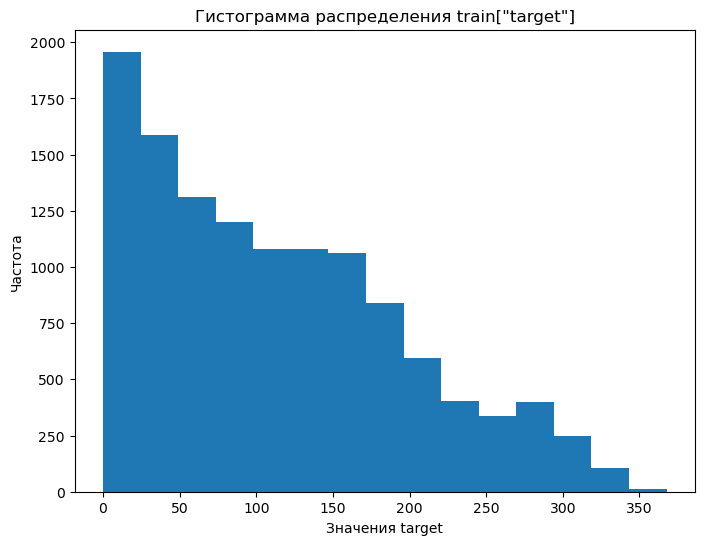

In [69]:
plt.figure(figsize=(8, 6))
plt.hist(y_pred, bins=15)  
plt.xlabel('Значения target')
plt.ylabel('Частота')
plt.title('Гистограмма распределения train["target"]')
plt.show()

In [81]:
submission = pd.DataFrame({'prediction': y_pred })

submission = submission.reset_index()

submission.rename(columns={'index': 'index', 'prediction': 'prediction'}, inplace=True)

submission.to_csv("submission.csv", index=False)

Должно быть outro — описание ваших вариантов по дальнейшему улучшению вашего итогового подхода с такими пунктами:
1) идея №1, которая может улучшить метрику, как ее реализовать (что для этого нужно сделать);
2) идея №2, которая может улучшить метрику, как ее реализовать (что для этого нужно сделать);
3) идея №3, которая может улучшить метрику, как ее реализовать (что для этого нужно сделать).

4. Ваш ник на Kaggle и скриншот с итоговой позицией на leaderboard (! важно — после завершения соревнования).
Написать в формате: ник ваш_ник, позиция 4.
(4 как пример итоговой позиции).

**Outro: Варианты для дальнейшего улучшения итогового подхода**

1. **Идея №1: Дополнительное расширение feature engineering**  
   - **Как улучшить метрику:** Создание и добавление новых признаков может помочь модели лучше улавливать сложные зависимости в данных.  
   - **Как реализовать:** Провести детальный анализ корреляций и взаимосвязей между признаками, добавить агрегированные статистики (например, средние значения, медианы по категориям), взаимодействия между признаками, а также рассмотреть использование внешних данных (географические, сезонные факторы).

2. **Идея №2: Двухступенчатая модель**  
   - **Как улучшить метрику:** Разделение задачи на классификацию и регрессию позволяет более точно предсказывать значения, особенно если в данных присутствует большое количество нулевых или экстремальных значений.  
   - **Как реализовать:**  
     - **Этап 1:** Построить классификатор для определения, является ли целевое значение нулевым или положительным.  
     - **Этап 2:** Для объектов, у которых значение определено как положительное, обучить регрессионную модель для предсказания точного значения.  
   - *Примечание:* Этот подход уже дал базовый скор 10900 на незаконченной настройке, что указывает на его потенциал при дальнейшей доработке.

3. **Идея №3: Ансамблирование моделей**  
   - **Как улучшить метрику:** Комбинирование предсказаний нескольких моделей снижает риск переобучения и может стабилизировать итоговый результат.  
   - **Как реализовать:** Обучить несколько моделей (например, CatBoost, LightGBM, XGBoost) с различными параметрами, а затем объединить их предсказания с помощью методов стекинга или блендинга. Использовать мета-модель для финального агрегирования результатов, что позволит учесть сильные стороны каждой модели.